In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Create a Dataset with Natural Clusters
# -------------------------------------------------------------
# Let's create a dataset of 300 students from 6 classrooms (clusters)

np.random.seed(42)

data = {
    "student_id": range(1, 301),
    "classroom": np.repeat(["A", "B", "C", "D", "E", "F"], 50),
    "marks": np.random.normal(loc=70, scale=10, size=300)
}

df = pd.DataFrame(data)

print("Full Dataset:")
display(df.head())

# Distribution across classrooms
print("\nClassroom Counts in Population:")
print(df["classroom"].value_counts())

Full Dataset:


,student_id,classroom,marks
0,1,A,74.967142
1,2,A,68.617357
2,3,A,76.476885
3,4,A,85.230299
4,5,A,67.658466



Classroom Counts in Population:
classroom
A    50
B    50
C    50
D    50
E    50
F    50
Name: count, dtype: int64


In [4]:
# 2. Perform Cluster Sampling
# -------------------------------------------------------------
# Step 1: Identify clusters (classrooms)
clusters = df["classroom"].unique()

# Step 2: Randomly select some clusters
num_clusters_to_select = 2
selected_clusters = np.random.choice(clusters, size=num_clusters_to_select, replace=False)

print("\nSelected Clusters:", selected_clusters)


Selected Clusters: ['E' 'C']


In [6]:
# Step 3: Take ALL data from selected clusters
cluster_sample = df[df["classroom"].isin(selected_clusters)]

print("\nCluster Sample Data:")
display(cluster_sample.head())


Cluster Sample Data:


,student_id,classroom,marks
100,101,C,55.846293
101,102,C,65.793547
102,103,C,66.572855
103,104,C,61.977227
104,105,C,68.387143


In [7]:
# 3. Compare Sample Distribution with Population
# -------------------------------------------------------------
population_mean = df["marks"].mean()
sample_mean = cluster_sample["marks"].mean()

print("\nPopulation Mean:", population_mean)
print("Cluster Sample Mean:", sample_mean)


Population Mean: 69.94451440918759
Cluster Sample Mean: 70.55840886705631


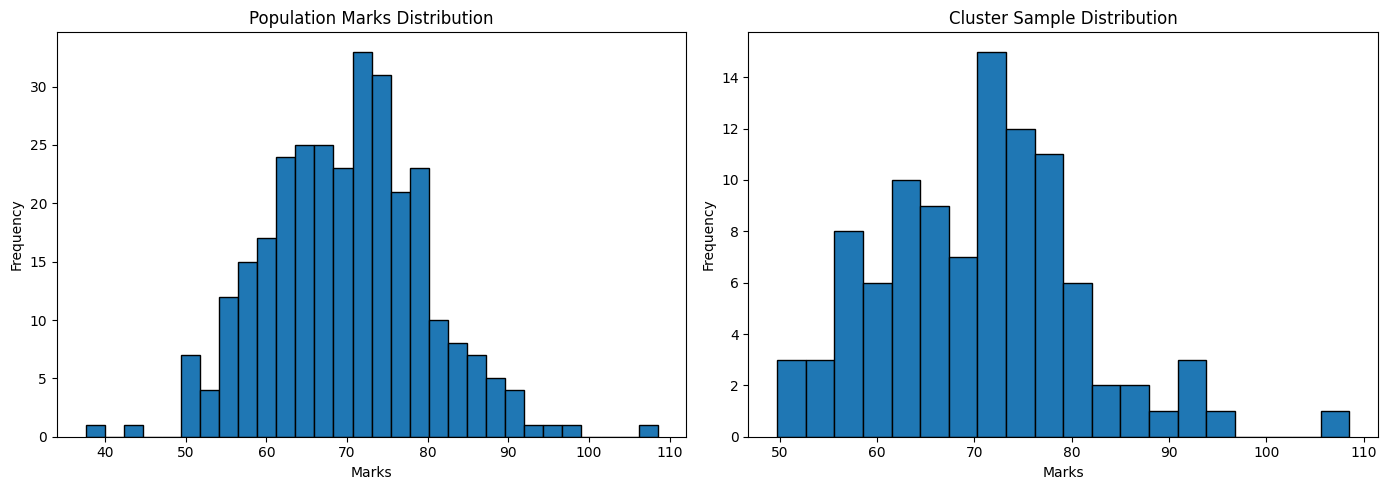

In [8]:
# 4. Visualization
# -------------------------------------------------------------

plt.figure(figsize=(14,5))

# Population
plt.subplot(1,2,1)
plt.hist(df["marks"], bins=30, edgecolor="black")
plt.title("Population Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")

# Cluster Sample
plt.subplot(1,2,2)
plt.hist(cluster_sample["marks"], bins=20, edgecolor="black")
plt.title("Cluster Sample Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()